# Simulación y exportación de datos: Etapa 1

**Proyecto:** `model_psbp_fd` · **Etapa:** `01_simulate` (Python) · **Aguas abajo:** `02_represent` (R + Splinets)

Primera etapa del pipeline. Reutiliza el paquete del proyecto (no reimplementa el DGP):

1. **Simula** una STF FAR(1) con `FARSimulator`.
2. **Estandariza** las curvas por columna (z-score *funcional*; distinta de la del espacio AR de la etapa 03).
3. **Exporta** el contrato de datos a `data/simulaciones/pipelines/{EXPERIMENT_ID}/`.
4. **Reporta** figuras de control en `reports/simulaciones/{EXPERIMENT_ID}/`.

## 1. Imports y raíz del proyecto

In [44]:
from __future__ import annotations

import os
import sys
import json
import time
import hashlib
import platform
import subprocess
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Lógica de dominio del proyecto (se REUTILIZA, no se reimplementa)
from model_psbp_fd.pipelines.simulation_pipeline_linear import (
    FunctionalDomain,
    FARSimulator,
    gaussian_integral_kernel,
    build_integral_matrix,
)

# Funciones de visualización ya existentes en el proyecto
from model_psbp_fd.graphics import (
    plot_empirical_sample,
    plot_fts_empirical,
    plot_mean_and_variance,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [45]:
def get_project_root(marker: str = "README.md") -> Path:
    '''Detecta la raíz del proyecto subiendo hasta encontrar `marker`.'''
    current = Path(os.getcwd()).resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    return current


PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT : {PROJECT_ROOT}")

PROJECT_ROOT : C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd


## 2. Configuración del experimento

In [46]:
# ── Identidad del experimento ─────────────────────────────────────────────────
BASENAME  = "Pipeline"
TT        = 1
SEED      = 4123

# Permite que el orquestador fije el ID (misma cadena en todas las etapas).
EXPERIMENT_ID = os.environ.get("PSBP_EXPERIMENT_ID") or f"{BASENAME}_{TT}"

print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")
print(f"SEED          : {SEED}")

EXPERIMENT_ID : Pipeline_1
SEED          : 4123


In [47]:
# ── Parámetros del DGP FAR(1) (idénticos al notebook de referencia) ───────────
FAR_PARAMS = {
    "n_curves":       100,
    "n_points":       100,
    "bandwidth":      0.05,
    "decay":          0.8,
    "temporal_slope": 4.0,
    "spatial_slope":  2.0,
    "intercept":      1.0,
    "noise_std":      0.2,
    "noise_type":     "smooth",
    "burn_in":        100,
}

# ── Estandarización funcional 
STANDARDIZE_CONFIG = {"method": "zscore_column", "ddof": 0}

for k, v in FAR_PARAMS.items():
    print(f"  {k:<16}: {v}")


  n_curves        : 100
  n_points        : 100
  bandwidth       : 0.05
  decay           : 0.8
  temporal_slope  : 4.0
  spatial_slope   : 2.0
  intercept       : 1.0
  noise_std       : 0.2
  noise_type      : smooth
  burn_in         : 100


## 3. Directorios 

In [48]:
# ── Raíces canónicas del proyecto (convención existente) ─────────────────────
RAW_ROOT      = PROJECT_ROOT / "data" / "simulaciones" / "pipelines"
ARTEFACT_ROOT = PROJECT_ROOT / "artefact" / "simulaciones"
REPORT_ROOT   = PROJECT_ROOT / "reports" / "simulaciones"

PATHS = {
    "raw":      RAW_ROOT / EXPERIMENT_ID,        # datos crudos, procesados y predichos
    "artefact": ARTEFACT_ROOT / EXPERIMENT_ID,   # artefactos, modelos, estandarizaciones
    "report":   REPORT_ROOT / EXPERIMENT_ID,     # imágenes y reportes
}

# Alias de conveniencia para esta etapa
DATA_DIR = PATHS["raw"]        # contrato de datos que LEE la etapa 02 (curves.csv, grid.csv, ...)
ART_DIR  = PATHS["artefact"]   # parámetros de estandarización (numérico-exactos)
FIG_DIR  = PATHS["report"]     # figuras de los reportes

for name, p in PATHS.items():
    p.mkdir(parents=True, exist_ok=True)
    print(f"  {name:8s} -> {p}")

  raw      -> C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\pipelines\Pipeline_1
  artefact -> C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\artefact\simulaciones\Pipeline_1
  report   -> C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\reports\simulaciones\Pipeline_1


## 4. Simulación FAR(1)

In [49]:
domain = FunctionalDomain.regular(n_points=FAR_PARAMS["n_points"])

Psi = build_integral_matrix(
    domain,
    gaussian_integral_kernel,
    bandwidth=FAR_PARAMS["bandwidth"],
    decay=FAR_PARAMS["decay"],
)

sim = FARSimulator(
    domain=domain,
    n_curves=FAR_PARAMS["n_curves"],
    Psi=Psi,
    trend="linear",
    trend_params={
        "temporal_slope": FAR_PARAMS["temporal_slope"],
        "spatial_slope":  FAR_PARAMS["spatial_slope"],
        "intercept":      FAR_PARAMS["intercept"],
    },
    noise_std=FAR_PARAMS["noise_std"],
    noise_type=FAR_PARAMS["noise_type"],
    burn_in=FAR_PARAMS["burn_in"],
    random_state=SEED,
)

X_raw = np.asarray(sim.simulate(), dtype=np.float64)   # (T, G)
grid  = np.asarray(domain.grid, dtype=np.float64)      # (G,)
T, G  = X_raw.shape

assert grid.shape[0] == G, "La grilla no coincide con el nº de columnas de X_raw"
print(f"X_raw : {X_raw.shape}  ->  T={T} curvas, G={G} puntos")
print(f"grid  : {grid.shape}  rango=[{grid.min():.4f}, {grid.max():.4f}]")

X_raw : (100, 100)  ->  T=100 curvas, G=100 puntos
grid  : (100,)  rango=[0.0000, 1.0000]


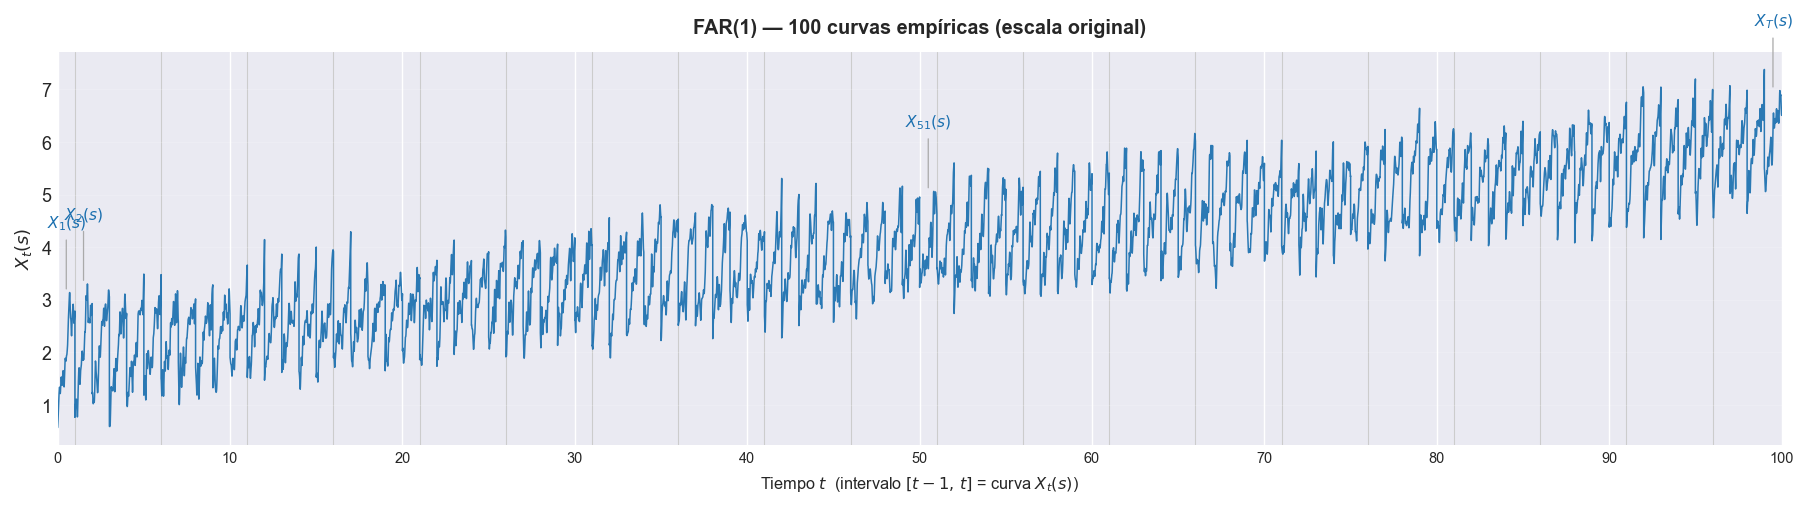

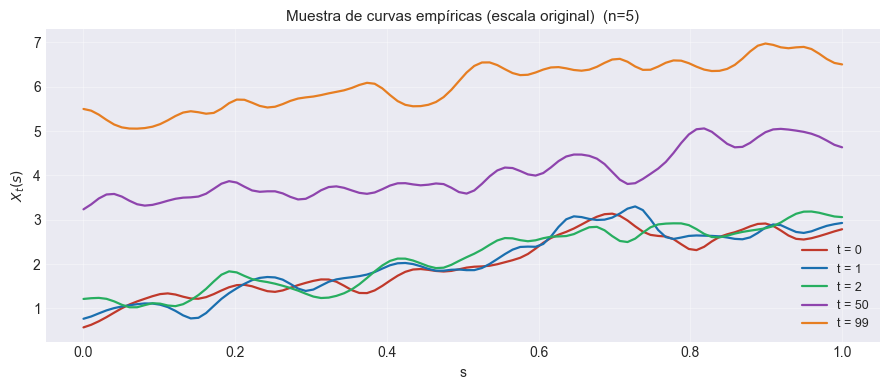

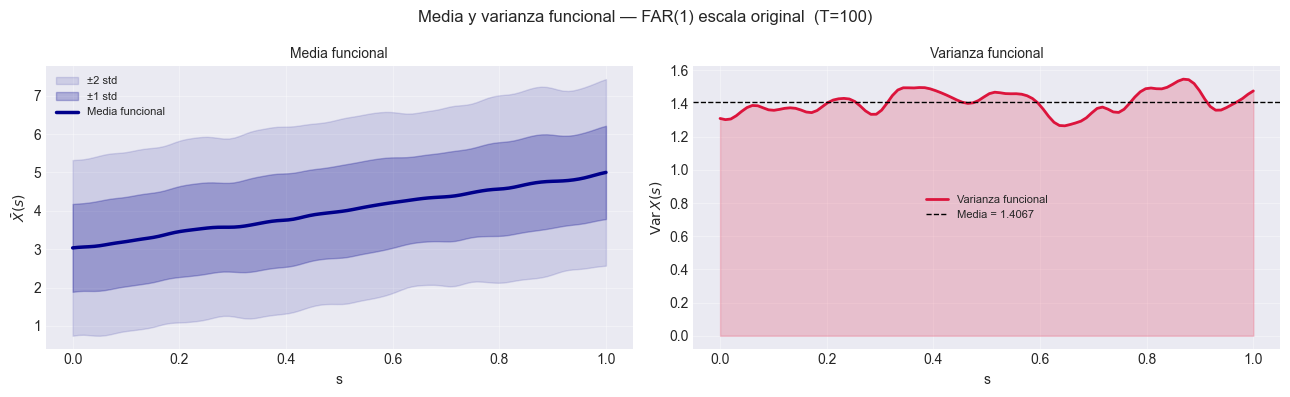

In [50]:
# ── Reporte de los datos empíricos (escala original) ─────────────────────────
# Usa las funciones del paquete graphics/ del proyecto (mismas firmas que el
# notebook de referencia 00_11).
highlight_idx = [0, 1, T // 2, T - 1]
sample_idx    = [0, 1, 2, T // 2, T - 1]

# Serie de tiempo funcional empírica (curvas desplazadas)
plot_fts_empirical(
    X_raw, grid,
    highlight_idx=highlight_idx,
    title=f"FAR(1) — {T} curvas empíricas (escala original)",
    separator_every=5,
    save_path=str(FIG_DIR / "01_fts_empirica_raw.png"),
)
plt.show()

# Muestra de curvas empíricas
plot_empirical_sample(
    X_raw, grid,
    sample_idx=sample_idx,
    title="Muestra de curvas empíricas (escala original)",
    save_path=str(FIG_DIR / "02_muestra_empirica_raw.png"),
)
plt.show()

# Media y varianza funcional
plot_mean_and_variance(
    X_raw, grid,
    show_std1=True, show_std2=True,
    title="Media y varianza funcional — FAR(1) escala original",
    save_path=str(FIG_DIR / "03_media_varianza_raw.png"),
)
plt.show()

## 5. Estandarización funcional (z-score por columna)

Para cada punto del dominio `g`, se estandariza la serie temporal `X[:, g]` restando
su media y dividiendo por su desviación (a lo largo de `t`). El resultado `X` es la
matriz que la etapa 02 proyectará sobre la base ortonormal Splinets.

In [51]:
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0, ddof=STANDARDIZE_CONFIG["ddof"])

zero_var = np.where(X_std == 0)[0]
if zero_var.size:
    raise ValueError(f"Columnas con varianza nula (no estandarizables): {zero_var.tolist()}")

X = (X_raw - X_mean) / X_std   # curvas estandarizadas (T, G)

# Diagnósticos de la estandarización (deben ser ~0)
chk_mean = float(np.abs(X.mean(axis=0)).max())
chk_std  = float(np.abs(X.std(axis=0, ddof=STANDARDIZE_CONFIG["ddof"]) - 1).max())
print(f"X estandarizada : {X.shape}")
print(f"  max|media|   = {chk_mean:.2e}  (debe ~ 0)")
print(f"  max|std-1|   = {chk_std:.2e}  (debe ~ 0)")

X estandarizada : (100, 100)
  max|media|   = 2.64e-15  (debe ~ 0)
  max|std-1|   = 4.44e-16  (debe ~ 0)


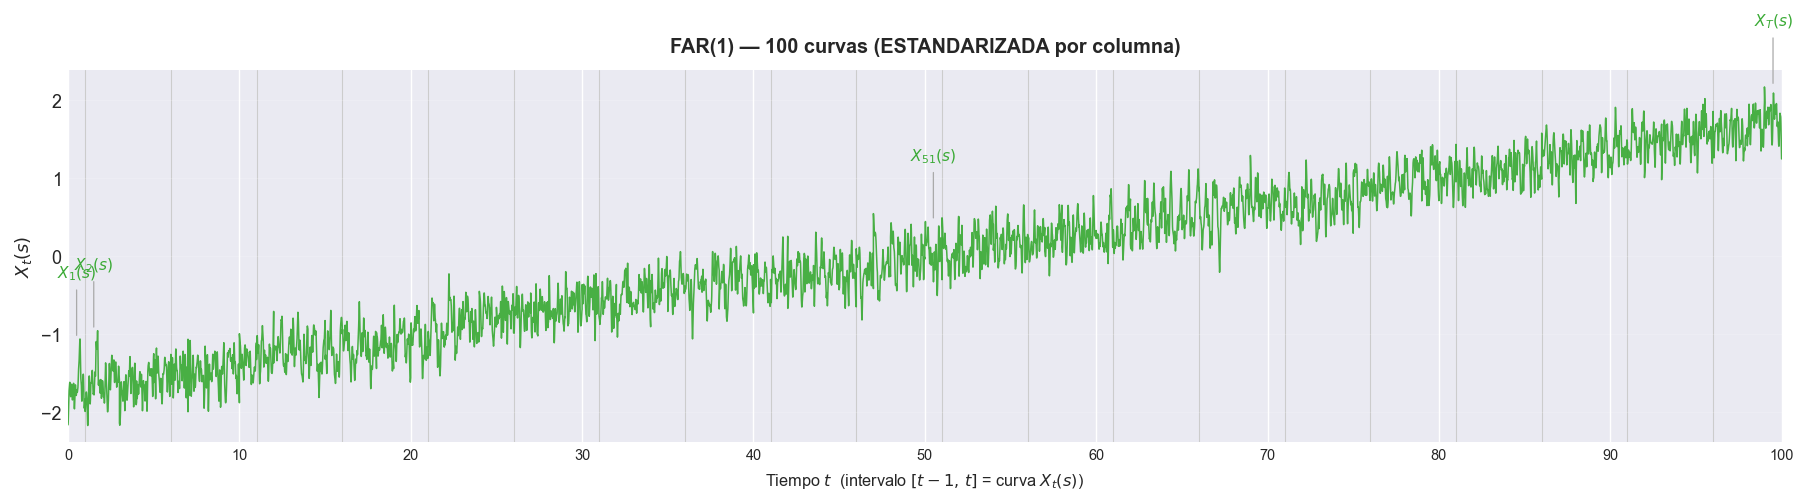

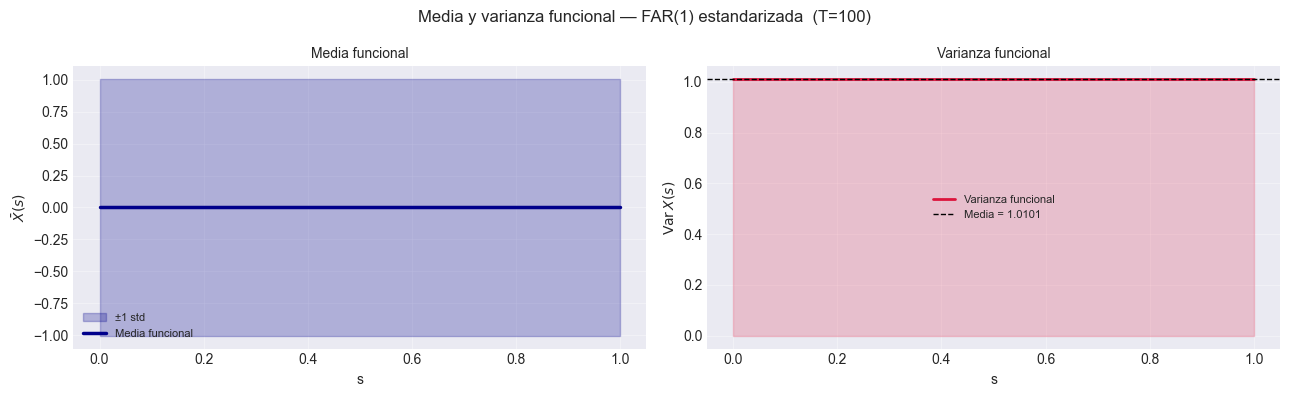

In [52]:
# ── Reporte de los datos estandarizados (z-score por columna) ────────────────
highlight_idx = [0, 1, T // 2, T - 1]

# Serie de tiempo funcional estandarizada
plot_fts_empirical(
    X, grid,
    highlight_idx=highlight_idx,
    color="#3aaa35",
    title=f"FAR(1) — {T} curvas (ESTANDARIZADA por columna)",
    separator_every=5,
    save_path=str(FIG_DIR / "04_fts_empirica_std.png"),
)
plt.show()

# Media y varianza funcional estandarizada (media ~0, std ~1)
plot_mean_and_variance(
    X, grid,
    show_std1=True,
    title="Media y varianza funcional — FAR(1) estandarizada",
    save_path=str(FIG_DIR / "05_media_varianza_std.png"),
)
plt.show()

## 6. Exportación al contrato de intercambio

**Disciplina anti-bugs de orientación:** todos los CSV se escriben con
**filas = tiempo/observación**, **columnas = variable/grilla**, con cabecera y sin
columna de índice. La etapa que lee valida `shape` contra el `manifest`.

In [53]:
def _sha256(path: Path) -> str:
    h = hashlib.sha256()
    h.update(Path(path).read_bytes())
    return h.hexdigest()


def _git_commit() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"],
            text=True, stderr=subprocess.DEVNULL,
        ).strip()
    except Exception:
        return "unknown"


def _env_info() -> dict:
    return {
        "python":   platform.python_version(),
        "numpy":    np.__version__,
        "pandas":   pd.__version__,
        "platform": platform.platform(),
    }

In [54]:
# ── 1) datos_transform.csv : curvas ESTANDARIZADAS (T x G) ───────────────────
g_cols = [f"g_{j + 1:04d}" for j in range(G)]
pd.DataFrame(X, columns=g_cols).to_csv(DATA_DIR / "datos_transform.csv", index=False)

# ── 2) datos_raw.csv : curvas crudas (trazabilidad) ──────────────────────────
pd.DataFrame(X_raw, columns=g_cols).to_csv(DATA_DIR / "datos_raw.csv", index=False)

# ── 3) grid.csv : puntos del dominio (G x 1) ─────────────────────────────────
pd.DataFrame({"tau": grid}).to_csv(DATA_DIR / "grid.csv", index=False)

# ── 4) standardization.npz : parámetros EXACTOS de des-estandarización ───────
np.savez(
    ART_DIR / "standardization.npz",
    mean=X_mean, std=X_std, ddof=np.array(STANDARDIZE_CONFIG["ddof"]),
)

# ── 5) true_params.json : todo lo necesario para comparar en la etapa 04 ─────
true_params = {
    "experiment_id": EXPERIMENT_ID,
    "seed": SEED,
    "T": int(T),
    "G": int(G),
    "n_points": int(FAR_PARAMS["n_points"]),
    "domain_range": [float(grid.min()), float(grid.max())],
    "grid_n": int(grid.shape[0]),
    "far_params": FAR_PARAMS,
    "operator": {
        "type": "gaussian_integral_kernel",
        "bandwidth": FAR_PARAMS["bandwidth"],
        "decay":     FAR_PARAMS["decay"],
    },
    "trend": {
        "type":           "linear",
        "temporal_slope": FAR_PARAMS["temporal_slope"],
        "spatial_slope":  FAR_PARAMS["spatial_slope"],
        "intercept":      FAR_PARAMS["intercept"],
    },
    "noise": {"std": FAR_PARAMS["noise_std"], "type": FAR_PARAMS["noise_type"]},
    "standardization": {
        "method":       STANDARDIZE_CONFIG["method"],
        "ddof":         STANDARDIZE_CONFIG["ddof"],
        "applied_to":   "datos_transform.csv",
        "npz_artifact": "standardization.npz",
        "mean":         X_mean.tolist(),
        "std":          X_std.tolist(),
    },
    "curves_are_standardized": True,
    "raw_curves_artifact":     "datos_raw.csv",
}
(DATA_DIR / "true_params.json").write_text(
    json.dumps(true_params, indent=2), encoding="utf-8"
)

print("Artefactos de datos escritos en:", DATA_DIR)
for name in ("datos_transform.csv", "datos_raw.csv", "grid.csv", "true_params.json"):
    print(f"  - {name}")
print("Artefacto de estandarización en:", ART_DIR / "standardization.npz")

Artefactos de datos escritos en: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\pipelines\Pipeline_1
  - datos_transform.csv
  - datos_raw.csv
  - grid.csv
  - true_params.json
Artefacto de estandarización en: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\artefact\simulaciones\Pipeline_1\standardization.npz


In [55]:
# ── 6) manifest.json : metadatos verificables para la etapa siguiente ─────────
artifacts = []
for name, shape in (
    ("datos_transform.csv", [int(T), int(G)]),
    ("datos_raw.csv",       [int(T), int(G)]),
    ("grid.csv",            [int(G), 1]),
    ("true_params.json",    None),
):
    path = DATA_DIR / name
    entry = {"name": name, "sha256": _sha256(path)}
    if shape is not None:
        entry["shape"] = shape
        entry["dtype"] = "float64"
    artifacts.append(entry)

# Artefacto externo (vive en artefact/, no en raw/): se referencia por ruta relativa
std_npz = ART_DIR / "standardization.npz"
artifacts.append({
    "name": "standardization.npz",
    "root": "artefact",
    "rel_path": str(std_npz.relative_to(PROJECT_ROOT)),
    "sha256": _sha256(std_npz),
})

manifest = {
    "stage": "01_simulation",
    "experiment_id": EXPERIMENT_ID,
    "produced_at": datetime.now(timezone.utc).isoformat(),
    "language": "Python",
    "git_commit": _git_commit(),
    "environment": _env_info(),
    "seed": {"simulation": SEED, "fit": None},
    "paths": {
        "raw":      str(DATA_DIR.relative_to(PROJECT_ROOT)),
        "artefact": str(ART_DIR.relative_to(PROJECT_ROOT)),
        "report":   str(FIG_DIR.relative_to(PROJECT_ROOT)),
    },
    "params": {
        "T": int(T),
        "G": int(G),
        "n_points": int(FAR_PARAMS["n_points"]),
        "n_curves": int(FAR_PARAMS["n_curves"]),
        "burn_in":  int(FAR_PARAMS["burn_in"]),
    },
    "artifacts": artifacts,
    "checks": {
        "standardization":       STANDARDIZE_CONFIG["method"],
        "std_max_abs_mean":      chk_mean,
        "std_max_abs_std_minus_1": chk_std,
    },
}
(DATA_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)
print("manifest.json escrito en:", DATA_DIR / "manifest.json")
print(json.dumps(manifest, indent=2))

manifest.json escrito en: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\pipelines\Pipeline_1\manifest.json
{
  "stage": "01_simulation",
  "experiment_id": "Pipeline_1",
  "produced_at": "2026-06-04T15:06:04.839163+00:00",
  "language": "Python",
  "git_commit": "9c9f819",
  "environment": {
    "python": "3.11.2",
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "platform": "Windows-10-10.0.19045"
  },
  "seed": {
    "simulation": 4123,
    "fit": null
  },
  "paths": {
    "raw": "data\\simulaciones\\pipelines\\Pipeline_1",
    "artefact": "artefact\\simulaciones\\Pipeline_1",
    "report": "reports\\simulaciones\\Pipeline_1"
  },
  "params": {
    "T": 100,
    "G": 100,
    "n_points": 100,
    "n_curves": 100,
    "burn_in": 100
  },
  "artifacts": [
    {
      "name": "datos_transform.csv",
      "sha256": "81192d3a548e54dd55199ffebf54355bef6020d22597737e4279cc2553a73bee",
      "shape": [
        100,
        100
      ],
      "dtype": "float64"
    },
 

## 7. Verificación de los artefactos (fail-fast)

In [56]:
# 1) Re-lectura y validación de shapes/dtypes
datos_transform_io = pd.read_csv(DATA_DIR / "datos_transform.csv")
datos_raw_io       = pd.read_csv(DATA_DIR / "datos_raw.csv")
grid_io            = pd.read_csv(DATA_DIR / "grid.csv")

assert datos_transform_io.shape == (T, G), f"datos_transform.csv shape {datos_transform_io.shape} != {(T, G)}"
assert grid_io.shape == (G, 1),            f"grid.csv shape {grid_io.shape} != {(G, 1)}"
assert list(datos_transform_io.columns) == g_cols, "Cabeceras de datos_transform.csv no coinciden"
assert (datos_transform_io.dtypes == np.float64).all(), "datos_transform.csv no es float64"

# 2) Hashes de los artefactos coinciden con el manifest
man_io = json.loads((DATA_DIR / "manifest.json").read_text(encoding="utf-8"))
for a in man_io["artifacts"]:
    if a.get("root") == "artefact":
        target = PROJECT_ROOT / a["rel_path"]
    else:
        target = DATA_DIR / a["name"]
    assert _sha256(target) == a["sha256"], f"Hash de {a['name']} no coincide con el manifest"

# 3) Round-trip de estandarización: X*std + mean == X_raw
tp      = json.loads((DATA_DIR / "true_params.json").read_text(encoding="utf-8"))
mean_io = np.asarray(tp["standardization"]["mean"], dtype=np.float64)
std_io  = np.asarray(tp["standardization"]["std"],  dtype=np.float64)
X_destd = datos_transform_io.to_numpy() * std_io + mean_io
rt_err  = float(np.max(np.abs(X_destd - datos_raw_io.to_numpy())))
assert rt_err < 1e-8, f"Round-trip de estandarización falló (err={rt_err:.2e})"

# 4) El .npz (numérico-exacto) coincide con true_params.json
z = np.load(ART_DIR / "standardization.npz")
assert np.allclose(z["mean"], mean_io) and np.allclose(z["std"], std_io), \
    "standardization.npz no coincide con true_params.json"

print("VERIFICACIÓN OK")
print(f"  datos_transform.csv : {datos_transform_io.shape}  float64")
print(f"  grid.csv            : {grid_io.shape}")
print(f"  hashes manifest     : coinciden")
print(f"  round-trip estd     : err_max={rt_err:.2e}  (< 1e-8)")
print(f"  standardization.npz : coincide con JSON")

VERIFICACIÓN OK
  datos_transform.csv : (100, 100)  float64
  grid.csv            : (100, 1)
  hashes manifest     : coinciden
  round-trip estd     : err_max=8.88e-16  (< 1e-8)
  standardization.npz : coincide con JSON
